# import

In [2]:
# general import: 
import sys
import time
import os
import gc
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# quantum import:
from qiskit import QuantumCircuit
from qiskit.quantum_info import DensityMatrix
from qiskit.visualization import plot_state_city, plot_state_hinton, plot_state_qsphere

In [4]:
# ML import:
import tensorflow as tf
import keras
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import sklearn
from sklearn.model_selection import train_test_split

In [5]:
# custom helper and libraries:
sys.path.append('../src')
from povm_sampling import *
from statesprep import *
from vae import *
from plots import *
from utils import *
from mle import *

# GHZ analysis

In [ ]:
def genera_dataset(p_exact, seed_data, n_samples=500):
    samples = sample_povm(p_exact, n_samples, seed=seed_data)
    return samples

In [ ]:
def fit_mle(p_exact, samples, N):
    nll = make_nll(samples, N)

    dim = 2**N
    init_rho = np.eye(dim, dtype=complex) / dim
    p0 = rho_to_params(init_rho, N)

    m = Minuit(nll, *p0)
    m.errordef = Minuit.LIKELIHOOD
    m.print_level = 0
    m.migrad()
    if not m.valid:
        m.migrad()                                

    rho_mle = params_to_rho(np.array(m.values), N)
    p_mle = povm_probability(rho_mle, N)
    fc    = classical_fidelity(p_exact, p_mle)

    return float(fc)

In [ ]:
def fit_vae(p_exact, samples, N, seed_train, n_gen=50_000):
    keras.utils.set_random_seed(seed_train)        # <-- fissa init/shuffle

    onehot_samples = samples_to_onehot(samples, N)

    X_train, X_test = train_test_split(onehot_samples, test_size=0.2,
                                       random_state=42)

    LATENT_DIM = 16
    HIDDEN_DIM = 96
    WARMUP_EPOCHS = 50
    TOTAL_EPOCHS = 500
    BATCH_SIZE = 100
    LEARNING_RATE = 1e-3
    BETA_MAX = 0.85

    vae = VAE(n_qubits=N, latent_dim=LATENT_DIM, hidden=HIDDEN_DIM)
    vae.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE))
    vae.build(input_shape=(None, 4*N))

    callbacks = [
        KLWarmup(beta_max=BETA_MAX, warmup_epochs=WARMUP_EPOCHS),
        keras.callbacks.EarlyStopping(
            monitor='val_reconstruction_loss', mode='min', patience=50,
            restore_best_weights=True, start_from_epoch=WARMUP_EPOCHS),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_reconstruction_loss', mode='min',
            factor=0.5, patience=20, min_lr=1e-6),
    ]
    vae.fit(X_train, X_train, epochs=TOTAL_EPOCHS, batch_size=BATCH_SIZE,
            validation_data=(X_test, X_test), callbacks=callbacks, verbose=0)

    p_vae = vae.predict_dist(n_samples=n_gen, batch_size=50_000)
    fc = classical_fidelity(p_exact, p_vae)

    # libera grafo TF + RAM: in un kernel longevo clear_session() da solo non basta,
    # serve anche eliminare il modello e forzare il garbage collector.
    del vae
    keras.backend.clear_session()
    gc.collect()
    return float(fc)

In [ ]:
N = 3
qc = create_ghz_state(N)
rho_true = DensityMatrix(qc)
n_samples = 5000
p_exact = povm_probability(rho_true.data, N)

In [ ]:
B = 50                          # numero di dataset indipendenti (stats.md: 50-100)
N_GEN = 1_000_000                   # campioni VAE per stimare p_vae (>> n_samples, vedi stats.md)
SEED_TRAIN_FISSO = 123456  

rows = []
for b in range(B):
    samples = genera_dataset(p_exact=p_exact, seed_data=42 + b, n_samples=n_samples)
    fc_m = fit_mle(p_exact, samples, N)                                                  
    fc_v = fit_vae(p_exact, samples, N, seed_train=SEED_TRAIN_FISSO, n_gen=N_GEN)     

    # stesso dataset b per entrambi => confronto PAIRED
    rows.append(dict(method='MLE', b=b, N=n_samples, F_c=fc_m))
    rows.append(dict(method='VAE', b=b, N=n_samples, F_c=fc_v))

    if b % 1 == 0:
        print(f"{b+1}/{B}  F_c: MLE={fc_m:.4f}  VAE={fc_v:.4f}")

# UN solo CSV, colonna 'b' = indice replica
df = pd.DataFrame(rows)
df.to_csv(f'risultati_shot_N{n_samples}_B{B}.csv', index=False)
print("\nSalvato. Righe:", len(df))

1/50  F_c: MLE=0.9993  VAE=0.9890
2/50  F_c: MLE=0.9997  VAE=0.9893
3/50  F_c: MLE=0.9991  VAE=0.9906
4/50  F_c: MLE=0.9992  VAE=0.9880
5/50  F_c: MLE=0.9994  VAE=0.9900
6/50  F_c: MLE=0.9993  VAE=0.9865
7/50  F_c: MLE=0.9995  VAE=0.9858
8/50  F_c: MLE=0.9995  VAE=0.9910
9/50  F_c: MLE=0.9993  VAE=0.9882
10/50  F_c: MLE=0.9996  VAE=0.9906
11/50  F_c: MLE=0.9993  VAE=0.9885
12/50  F_c: MLE=0.9996  VAE=0.9887
13/50  F_c: MLE=0.9994  VAE=0.9895
14/50  F_c: MLE=0.9991  VAE=0.9891
15/50  F_c: MLE=0.9994  VAE=0.9905
16/50  F_c: MLE=0.9991  VAE=0.9906
17/50  F_c: MLE=0.9992  VAE=0.9886
18/50  F_c: MLE=0.9996  VAE=0.9887
19/50  F_c: MLE=0.9991  VAE=0.9896
20/50  F_c: MLE=0.9996  VAE=0.9895
21/50  F_c: MLE=0.9995  VAE=0.9890
22/50  F_c: MLE=0.9993  VAE=0.9905
23/50  F_c: MLE=0.9993  VAE=0.9887
24/50  F_c: MLE=0.9995  VAE=0.9891
25/50  F_c: MLE=0.9996  VAE=0.9895
26/50  F_c: MLE=0.9992  VAE=0.9881
27/50  F_c: MLE=0.9996  VAE=0.9885
28/50  F_c: MLE=0.9994  VAE=0.9900
29/50  F_c: MLE=0.9992  VAE=0

## analysis

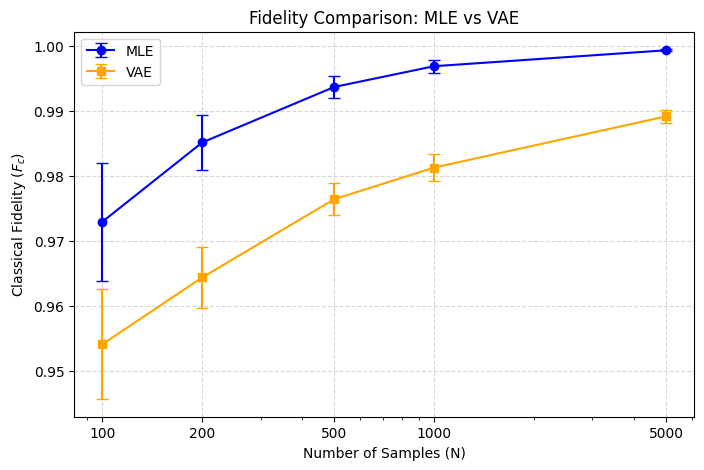

In [ ]:
# Definiamo la lista dei qubit (o shots) da analizzare
n_values = [100, 200, 500, 1000, 5000]

fc = []
s_fc = []
perc_fc = []

vae_fc = []
vae_s_fc = []
vae_perc_fc = []

for N in n_values:
    # Nota: ho corretto il nome del file usando f'{N}' per renderlo dinamico
    df = pd.read_csv(f"risultati_shot_N{N}_B50.csv")

    for met in ["MLE", "VAE"]:
        v = df.query("method == @met")["F_c"].values
        mu = v.mean()
        sigma = v.std(ddof=1)
        lo, hi = np.percentile(v, [2.5, 97.5])

        if met == "MLE":
            fc.append(mu)
            s_fc.append(sigma)
            perc_fc.append([lo, hi])
        else:
            vae_fc.append(mu)
            vae_s_fc.append(sigma)
            vae_perc_fc.append([lo, hi])

# --- CORREZIONE DEL GRAFICO ---
plt.figure(figsize=(8, 5))

# Plot per MLE: usiamo la lista completa n_values come asse X
plt.errorbar(
    n_values, fc, yerr=s_fc, fmt="-o", capsize=4, label="MLE", color="blue"
)

# Plot per VAE: sullo stesso asse X
plt.errorbar(
    n_values,
    vae_fc,
    yerr=vae_s_fc,
    fmt="-s",
    capsize=4,
    label="VAE",
    color="orange",
)

# Ottimizzazioni per la tesi
plt.xlabel("Number of Samples (N)")
plt.ylabel("Classical Fidelity ($F_c$)")
plt.title("Fidelity Comparison: MLE vs VAE")
plt.xscale("log")  # Consigliato se i dati scalano da 100 a 5000
plt.xticks(n_values, labels=[str(n) for n in n_values])
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.show()



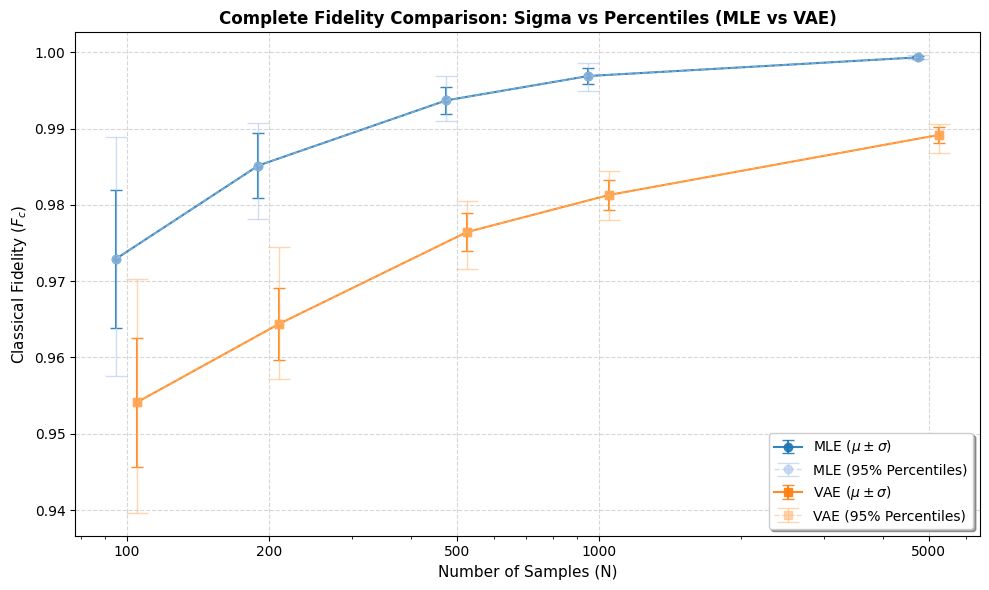

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

n_values = [100, 200, 500, 1000, 5000]

# Liste per accumulare i dati
fc = []
s_fc = []
perc_fc = []

vae_fc = []
vae_s_fc = []
vae_perc_fc = []

for N in n_values:
    df = pd.read_csv(f"risultati_shot_N{N}_b50.csv")

    for met in ["MLE", "VAE"]:
        v = df.query("method == @met")["F_c"].values
        mu = v.mean()
        sigma = v.std(ddof=1)
        lo, hi = np.percentile(v, [2.5, 97.5])

        if met == "MLE":
            fc.append(mu)
            s_fc.append(sigma)
            perc_fc.append([lo, hi])
        else:
            vae_fc.append(mu)
            vae_s_fc.append(sigma)
            vae_perc_fc.append([lo, hi])

# Conversione in array NumPy per i calcoli vettoriali
n_values = np.array(n_values, dtype=float)
fc = np.array(fc)
s_fc = np.array(s_fc)
perc_fc = np.array(perc_fc)

vae_fc = np.array(vae_fc)
vae_s_fc = np.array(vae_s_fc)
vae_perc_fc = np.array(vae_perc_fc)

# Calcolo errori asimmetrici per i percentili
err_mle_perc = np.array([fc - perc_fc[:, 0], perc_fc[:, 1] - fc])
err_vae_perc = np.array([vae_fc - vae_perc_fc[:, 0], vae_perc_fc[:, 1] - vae_fc])

# --- JITTERING (Disallineamento X per evitare sovrapposizioni grafiche) ---
# Moltiplichiamo leggermente in scala logaritmica per separare MLE e VAE visivamente
x_mle = n_values * 0.95
x_vae = n_values * 1.05

# --- COSTRUZIONE GRAFICO SOVRAPPOSTO ---
plt.figure(figsize=(10, 6))

# 1. MLE con Deviazione Standard (Sigma)
plt.errorbar(
    x_mle,
    fc,
    yerr=s_fc,
    fmt="-o",
    capsize=4,
    label=r"MLE ($\mu \pm \sigma$)",
    color="#1f77b4",
    alpha=0.9,
    linewidth=1.5,
)

# 2. MLE con Intervalli di Confidenza (Percentili 2.5% - 97.5%)
plt.errorbar(
    x_mle,
    fc,
    yerr=err_mle_perc,
    fmt="--o",
    capsize=8,
    label="MLE (95% Percentiles)",
    color="#aec7e8",
    alpha=0.6,
    linewidth=1,
)

# 3. VAE con Deviazione Standard (Sigma)
plt.errorbar(
    x_vae,
    vae_fc,
    yerr=vae_s_fc,
    fmt="-s",
    capsize=4,
    label=r"VAE ($\mu \pm \sigma$)",
    color="#ff7f0e",
    alpha=0.9,
    linewidth=1.5,
)

# 4. VAE con Intervalli di Confidenza (Percentili 2.5% - 97.5%)
plt.errorbar(
    x_vae,
    vae_fc,
    yerr=err_vae_perc,
    fmt="--s",
    capsize=8,
    label="VAE (95% Percentiles)",
    color="#ffbb78",
    alpha=0.6,
    linewidth=1,
)

# Ottimizzazioni per la leggibilità aziendale/accademica
plt.xlabel("Number of Samples (N)", fontsize=11)
plt.ylabel("Classical Fidelity ($F_c$)", fontsize=11)
plt.title(
    "Complete Fidelity Comparison: Sigma vs Percentiles (MLE vs VAE)",
    fontsize=12,
    fontweight="bold",
)
plt.xscale("log")
plt.xticks(n_values, labels=[str(int(n)) for n in n_values])
plt.grid(True, linestyle="--", alpha=0.5)

# Posiziona la legenda in basso a destra per non coprire i dati stabili vicini a 1.0
plt.legend(loc="lower right", frameon=True, shadow=True, facecolor="white")

plt.tight_layout()
plt.show()

# analisi: spiegato Intervalli confidenza, dispersione...

questa cella spiega differenze tra dispersione, intervallo di confidenza.. by claudio

credo che per il nostro problema, forse vale la pena o parlade di semplice sigma, o di percentili.. ma non si tratta in ogni caso di intervalli di confidenza, ne credo abbia senso usarlo come definizione

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

# -----------------------------------------------------------------------------
# ESEMPIO: df ha colonne ['b', 'method', 'F_c']
# con B dataset indipendenti e due metodi (MLE, VAE)
# -----------------------------------------------------------------------------
df = pd.read_csv('risultati_shot_N500_b50.csv')


for met in ['MLE', 'VAE']:
    v = df.query("method == @met")['F_c'].values
    B = len(v)

    # -------------------------------------------------------------------------
    # 1. STATISTICHE DI BASE
    # -------------------------------------------------------------------------
    mu    = v.mean()   # media campionaria — stima di E[F_c]
    sigma = v.std(ddof=1)  # deviazione standard campionaria (ddof=1 = correzione Bessel)
                           # descrive quanto variano i SINGOLI valori di F_c tra dataset

    # -------------------------------------------------------------------------
    # 2. INTERVALLO PERCENTILICO (dispersione empirica)
    #
    # Prende il 2.5° e 97.5° percentile dei valori grezzi di F_c.
    # Risponde a: "in quale range cade il 95% dei singoli esperimenti?"
    # NON è un'affermazione su mu — descrive la variabilità dei dati.
    # Non assume gaussianità — legge direttamente la distribuzione empirica.
    # Larghezza ~ 2 * sigma (per distribuzioni simmetriche).
    # -------------------------------------------------------------------------
    p_lo, p_hi = np.percentile(v, [2.5, 97.5])

    # -------------------------------------------------------------------------
    # 3. INTERVALLO DI CONFIDENZA AL 95% SULLA MEDIA (CI frequentista)
    #
    # Risponde a: "dove cade la vera media mu con probabilità 95%?"
    # Deriva dal fatto che la statistica pivotale
    #
    #   T = (F_bar - mu) / (sigma_hat / sqrt(B))
    #
    # segue una distribuzione t di Student con B-1 gradi di libertà.
    # Invertendo si ottiene: mu in [F_bar +/- t_0.975 * sigma/sqrt(B)]
    #
    # La chiave è sigma/sqrt(B) — l'errore standard della media (SEM):
    # con B dataset la media e' stimata B volte piu' precisamente
    # rispetto al singolo valore. Percio' il CI e' molto piu' stretto
    # dell'intervallo percentilico (fattore ~sqrt(B)).
    #
    # t_0.975 invece di z_0.975 = 1.96 perche' sigma e' stimata dai dati
    # (incertezza aggiuntiva) — per B grande convergono.
    # -------------------------------------------------------------------------
    sem = stats.sem(v)  # errore standard della media = sigma / sqrt(B)
    ci_lo, ci_hi = stats.t.interval(0.95, df=B-1, loc=mu, scale=sem)

    # t critico esplicito per trasparenza
    t_crit = stats.t.ppf(0.975, df=B-1)

    print(f"\n{'='*55}")
    print(f"Metodo: {met}   (B = {B} dataset)")
    print(f"{'='*55}")
    print(f"  Media F_c          : {mu:.4f}")
    print(f"  Std (singoli val.) : {sigma:.4f}   <- dispersione dei dati")
    print(f"  SEM (sigma/sqrt B) : {sem:.4f}   <- incertezza sulla media")
    print(f"  t_0.975 (df={B-1:2d})   : {t_crit:.4f}")
    print()
    print(f"  Intervallo percentilico 95% : [{p_lo:.4f}, {p_hi:.4f}]")
    print(f"  -> 'il 95% dei singoli F_c cade qui'")
    print(f"  -> larghezza = {p_hi - p_lo:.4f}  (~ 2 * 2sigma)")
    print()
    print(f"  Intervallo di confidenza 95%: [{ci_lo:.4f}, {ci_hi:.4f}]")
    print(f"  -> 'la vera media mu cade qui con prob. 95%'")
    print(f"  -> larghezza = {ci_hi - ci_lo:.4f}  (~ {(p_hi-p_lo)/(ci_hi-ci_lo):.1f}x piu' stretto del percentilico)")

# -----------------------------------------------------------------------------
# CONFRONTO PAIRED: VAE vs MLE sugli stessi dataset
#
# Poiche' i B dataset sono gli stessi per entrambi i metodi,
# il confronto naturale e' sulla DIFFERENZA paired delta_b = F_c^VAE_b - F_c^MLE_b.
# Questo elimina la variabilita' dovuta al dataset specifico
# e isola la differenza tra i metodi.
# -----------------------------------------------------------------------------
piv   = df.pivot_table(index='b', columns='method', values='F_c')
delta = (piv['VAE'] - piv['MLE']).values

print(f"\n{'='*55}")
print("CONFRONTO PAIRED: Delta F_c = VAE - MLE")
print(f"{'='*55}")
print(f"  Media delta        : {delta.mean():.4f}")
print(f"  Std delta          : {delta.std(ddof=1):.4f}")
print(f"  Frazione VAE > MLE : {(delta > 0).mean():.2%}")

# CI sulla differenza media — risponde a:
# "la differenza media tra VAE e MLE e' significativamente diversa da 0?"
ci_d_lo, ci_d_hi = stats.t.interval(0.95, df=len(delta)-1,
                                      loc=delta.mean(),
                                      scale=stats.sem(delta))
print(f"  CI 95% su delta    : [{ci_d_lo:.4f}, {ci_d_hi:.4f}]")
if ci_d_lo > 0:
    print(f"  -> CI non include 0: VAE significativamente migliore")
elif ci_d_hi < 0:
    print(f"  -> CI non include 0: MLE significativamente migliore")
else:
    print(f"  -> CI include 0: differenza non significativa al 95%")

# Test di Wilcoxon signed-rank — alternativa non parametrica al t-test paired
# non assume gaussianita' della differenza
stat_w, pval_w = stats.wilcoxon(piv['VAE'].values, piv['MLE'].values)
print(f"\n  Wilcoxon signed-rank test:")
print(f"  statistica = {stat_w:.2f},  p-value = {pval_w:.4f}")
if pval_w < 0.05:
    print(f"  -> differenza statisticamente significativa (p < 0.05)")
else:
    print(f"  -> differenza non significativa (p >= 0.05)")


Metodo: MLE   (B = 50 dataset)
  Media F_c          : 0.9937
  Std (singoli val.) : 0.0017   <- dispersione dei dati
  SEM (sigma/sqrt B) : 0.0002   <- incertezza sulla media
  t_0.975 (df=49)   : 2.0096

  Intervallo percentilico 95% : [0.9910, 0.9969]
  -> 'il 95% dei singoli F_c cade qui'
  -> larghezza = 0.0059  (~ 2 * 2sigma)

  Intervallo di confidenza 95%: [0.9932, 0.9942]
  -> 'la vera media mu cade qui con prob. 95%'
  -> larghezza = 0.0010  (~ 6.0x piu' stretto del percentilico)

Metodo: VAE   (B = 50 dataset)
  Media F_c          : 0.9764
  Std (singoli val.) : 0.0025   <- dispersione dei dati
  SEM (sigma/sqrt B) : 0.0004   <- incertezza sulla media
  t_0.975 (df=49)   : 2.0096

  Intervallo percentilico 95% : [0.9716, 0.9806]
  -> 'il 95% dei singoli F_c cade qui'
  -> larghezza = 0.0090  (~ 2 * 2sigma)

  Intervallo di confidenza 95%: [0.9757, 0.9771]
  -> 'la vera media mu cade qui con prob. 95%'
  -> larghezza = 0.0014  (~ 6.3x piu' stretto del percentilico)

CONFRONTO